# Hospital Readmission Prediction Project: Predictive Modeling


### **Author:**  Ari M.


### **Purpose & Goal:**
### The goal of this project is to see whether patient readmissions within 30 days can be predicted using hospital encounter data.
### I wanted to compare a few different modeling approaches and also see which patient patterns kept showing up across models.


### **Dataset used:** diabetic_features.csv

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
feature_path = kagglehub.dataset_download("datascienceam/diabetic-features-csv")

print("Path to dataset files:", feature_path)

Path to dataset files: /kaggle/input/datasets/datascienceam/diabetic-features-csv


In [3]:
# On local system
# df = pd.read_csv("../data/processed/diabetic_features.csv")

# On Kaggle
import os

feature_file_path = os.path.join(feature_path, "diabetic_features.csv")
df = pd.read_csv(feature_file_path, low_memory=False)

df.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,readmitted_30
0,6,25,1,1,41,0,1,0,0,0,...,True,False,False,False,False,False,False,True,False,0
1,1,1,7,3,59,0,18,0,0,0,...,True,False,False,False,False,False,False,False,True,0
2,1,1,7,2,11,5,13,2,0,1,...,True,False,False,False,False,False,False,True,True,0
3,1,1,7,2,44,1,16,0,0,0,...,True,False,False,False,False,False,False,False,True,0
4,1,1,7,1,51,0,8,0,0,0,...,True,False,False,False,False,False,False,False,True,0


## Target Variable

For the target variable, I’m using:

- `readmitted_30`
    - `0` = not readmitted
    - `1` = readmitted within 30 days

In [4]:
target = "readmitted_30"

y = df[target]
X = df.drop(columns=[target])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (101766, 2417)
Shape of y: (101766,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (81412, 2417)
Test shape: (20354, 2417)


## Train/Test Split

I used stratification because the positive class is relatively small (~11%).

Without stratifying, it would be easy to end up with slightly different class distributions between train and test sets.

## Feature Scaling

For Logistic Regression, I standardized the numeric columns before training.

I left the one-hot encoded columns alone since scaling those usually doesn’t add much value.

In [6]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Baseline Model 

I usually like starting with Logistic Regression first before jumping into more complex models.

It gives a decent baseline and is easier to interpret compared to ensemble methods.

In [7]:
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [8]:
y_pred = baseline_model.predict(X_test_scaled)
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

Because the dataset is imbalanced, accuracy alone would be misleading here.

I paid more attention to:
- recall
- precision
- ROC-AUC

Recall matters a lot in this problem since missing high-risk patients is probably worse than creating extra follow-up work.

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354



In [10]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6440849477943003


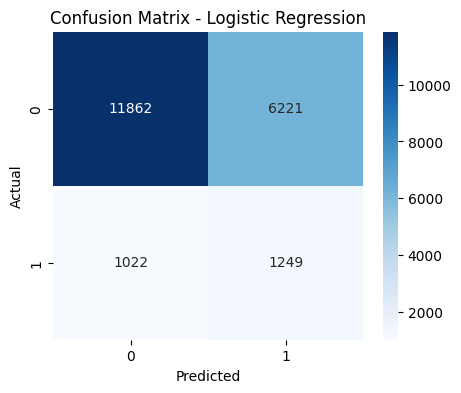

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Note on Reproducibility

One thing I noticed while rerunning this notebook across environments (local vs Kaggle) is that the confusion matrix values can shift slightly even when using the same random_state.

The differences are very small and don’t meaningfully change the interpretation of model performance, but it’s a good reminder that small variations can happen depending on execution environment, data loading behavior, or underlying library implementations.

To keep results as consistent as possible, I used:

random_state=42 for the train/test split
stratified sampling to preserve the class distribution (~11%)

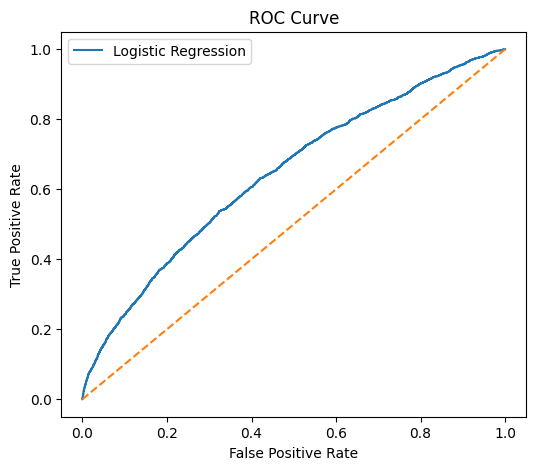

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

## Initial Interpretation

The model is finding some signal, but the separation between the two classes still looks pretty weak.

One thing that stood out is that recall is much better than I expected from a basic Logistic Regression model.

I also noticed that utilization-related variables kept appearing important throughout the project.

Features tied to prior hospital usage seem much more predictive than demographic variables.